In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings

warnings.filterwarnings("ignore") #ignoramos los mensajes de emergencia

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

sns.set_theme(style= "whitegrid", palette= "muted")
plt.rcParams["figure.figsize"] = (12,5)
plt.rcParams["figure.dpi"] = 120


In [3]:
#Carga de datos 

df_raw = pd.read_csv("../data/raw/resultados_admision_unmsm.csv")
df_fac = pd.read_csv("../data/raw/facultades.csv")

df = df_raw.merge(df_fac, on="escuela", how="left")#unimso las dos tablas basandonos en una columna comun (escuela)

# print(f"Postulantes        : {len(df):,}")
print(f"Columnas    : {df.shape[1]}")
print(f"Escuelas    : {df['escuela'].nunique()}")
print(f"Facultades  : {df['facultad'].nunique()}")
print(f"Sedes       : {df['sede'].nunique()}")

Columnas    : 8
Escuelas    : 95
Facultades  : 24
Sedes       : 3


In [4]:
#Limpieza y cladificacion de los postulantes

df["estado"] = df["observacion"].apply(lambda x: "INGRESÓ"  if x == "ALCANZÓ VACANTE"
else ("AUSENTE" if x == "AUSENTE" else "NO INGRESÓ"))

df["ingreso"] = (df["estado"] == "INGRESÓ").astype(int) # 1: ingresó, 0: no ingresó

print("== Distribución por estado ==")
print(df["estado"].value_counts())
print()
print(f"Total de postulantes    : {len(df):,}")
print(f"Cantidad de ingresantes : {df['ingreso'].sum()}")
print(f"Tasa de ingreso         : {df['ingreso'].mean()*100:.2f}%"  )

#de cada 100 personas 10 ingresaron.

== Distribución por estado ==
estado
NO INGRESÓ    23407
INGRESÓ        2772
AUSENTE         339
Name: count, dtype: int64

Total de postulantes    : 26,518
Cantidad de ingresantes : 2772
Tasa de ingreso         : 10.45%


In [5]:
# Manejo de ausentes y puntaje nulo

ausentes = df[df["estado"] == "AUSENTE"].copy()
df_activos = df[df["estado"] != "AUSENTE"].copy()

print(f"Registros con puntaje nulo             : {df["puntaje"].isnull().sum()}")
print(f"De esos son AUSENTES                   : {ausentes["puntaje"].isnull().sum()}")
print(f"Registros para analisis (sin ausentes) : {len(df_activos):,}")

Registros con puntaje nulo             : 339
De esos son AUSENTES                   : 339
Registros para analisis (sin ausentes) : 26,179


In [6]:
#estadistica descriptiva del puntaje

stats = df_activos["puntaje"].describe()
mediana = df_activos["puntaje"].median()#más robusta cuando hay outliers
coef_var = (df_activos["puntaje"].std() / df_activos["puntaje"].mean())*100 #dispercion como porcentaje de la media, una medida alta indica puntajes muy dispersos
#std que tan dispersos estan los puntajes

print("==Estadisticas del puntaje==")
print(f"Media               : {stats['mean']:.2f}")
print(f"Mediana             : {mediana:.2f}")
print(f"Desv. estándar      : {stats['std']:.2f}")
print(f"Coef.de variación  : {coef_var:.2f}%")
print(f"Puntaje minimo      : {stats['min']:.2f}")
print(f"Puntaje maximo      : {stats['max']:.2f}")
print(f"Percentil 25        : {stats['25%']:.2f}")
print(f"Percentil 75        : {stats['75%']:.2f}")


==Estadisticas del puntaje==
Media               : 805.52
Mediana             : 790.12
Desv. estándar      : 202.76
Coef.de variación  : 25.17%
Puntaje minimo      : 144.50
Puntaje maximo      : 1679.12
Percentil 25        : 661.12
Percentil 75        : 933.75


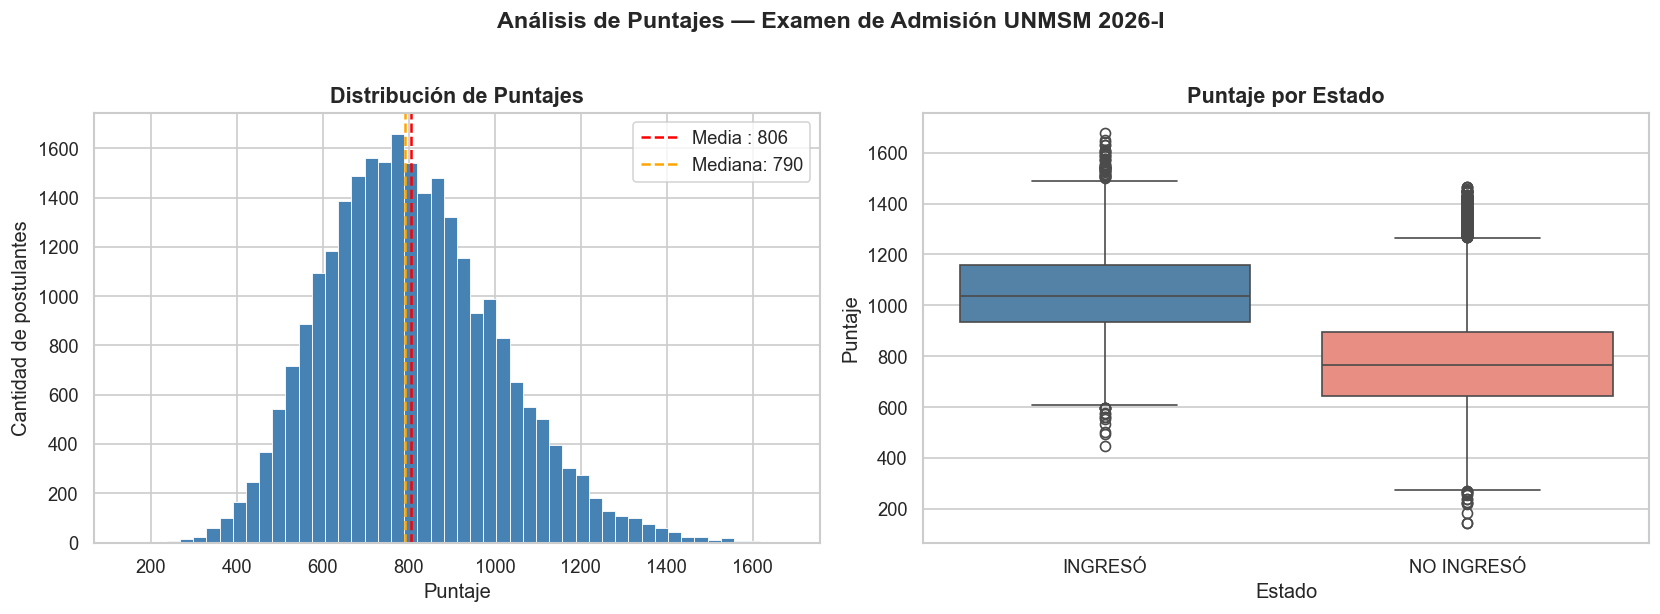

In [7]:
#Distribucion general del puntaje

fig, axes = plt.subplots(1,2,figsize = (14,5)) #figura de 1 fila 2 columnas

#1. Histograma
axes[0].hist(
    df_activos["puntaje"],
    bins = 50,
    color = "steelblue",
    edgecolor = "white",
    linewidth = 0.5
)

axes[0].axvline(
    df_activos["puntaje"].mean(),
    color = "red",
    linestyle = "--",
    linewidth = 1.5,
    label = f"Media : {df_activos['puntaje'].mean():.0f}"
)

axes[0].axvline(
    df_activos['puntaje'].median(),
    color='orange',
    linestyle='--',
    linewidth=1.5,
    label=f"Mediana: {df_activos['puntaje'].median():.0f}"

)

axes[0].set_title('Distribución de Puntajes', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Puntaje')
axes[0].set_ylabel('Cantidad de postulantes')
axes[0].legend()

#2. Boxplot por estado
sns.boxplot(
    data=df_activos,
    x='estado',
    y='puntaje',
    palette={'INGRESÓ': 'steelblue', 'NO INGRESÓ': 'salmon'},
    ax=axes[1]
)
axes[1].set_title('Puntaje por Estado', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Estado')
axes[1].set_ylabel('Puntaje')

plt.suptitle(
    'Análisis de Puntajes — Examen de Admisión UNMSM 2026-I',
    fontsize=14,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.savefig('../data/processed/distribucion_puntajes.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔍 Insight #1 — El puntaje solo no determina el ingreso

**Hallazgo:** Un postulante con puntaje alto puede no ingresar si postuló 
a una carrera de alta demanda. La tasa de ingreso global es 10.45% pero 
varía dramáticamente entre escuelas.

**Contexto:** El ingreso depende de la combinación puntaje + carrera. 
Cada escuela tiene su propio umbral de corte determinado por el ratio 
entre postulantes y vacantes disponibles.

**Implicancia:** La variable determinante no es el puntaje 
absoluto sino el puntaje relativo dentro de la carrera elegida. 
Un postulante debe evaluar su puntaje esperado contra el corte 
histórico de su carrera objetivo, no contra el promedio general.

In [8]:
# Tasa de ingreso por facultad
tasa_facultad = df_activos.groupby('facultad').agg(
    postulantes=('ingreso', 'count'),
    ingresantes=('ingreso', 'sum')
).reset_index()

tasa_facultad['tasa_ingreso'] = (
    tasa_facultad['ingresantes'] / tasa_facultad['postulantes'] * 100
).round(2)

tasa_facultad = tasa_facultad.sort_values('tasa_ingreso', ascending=False)

print(tasa_facultad.to_string(index=False))



                                            facultad  postulantes  ingresantes  tasa_ingreso
                                             QUÍMICA           51           28         54.90
                                    CIENCIAS FÍSICAS           64           35         54.69
                                CIENCIAS MATEMÁTICAS          491          208         42.36
                                                ARTE          104           35         33.65
                                  CIENCIAS CONTABLES         1255          338         26.93
                                   CIENCIAS SOCIALES          577          153         26.52
                                 CIENCIAS ECONÓMICAS         1088          209         19.21
                                           EDUCACIÓN          777          139         17.89
                               FARMACIA Y BIOQUÍMICA          439           74         16.86
                                  INGENIERÍA QUÍMICA          232     

## Corrección de calidad de dato — facultades.csv

**Problema identificado:** La Escuela Profesional de Arquitectura y Urbanismo 
apareció inicialmente como facultad independiente en `facultades.csv`.

**Causa:** Error en la generación del archivo fuente.

**Corrección:** Se actualizó `facultades.csv` asignando Arquitectura y Urbanismo 
a la Facultad de Ingeniería Geológica, Minera, Metalúrgica y Geográfica (FIGMMG), 
que es su facultad real según la estructura académica de la UNMSM.

**Impacto:** FIGMMG pasa de 996 a 1,585 postulantes y de 128 a 148 ingresantes. 
El número de facultades se reduce de 25 a 24.

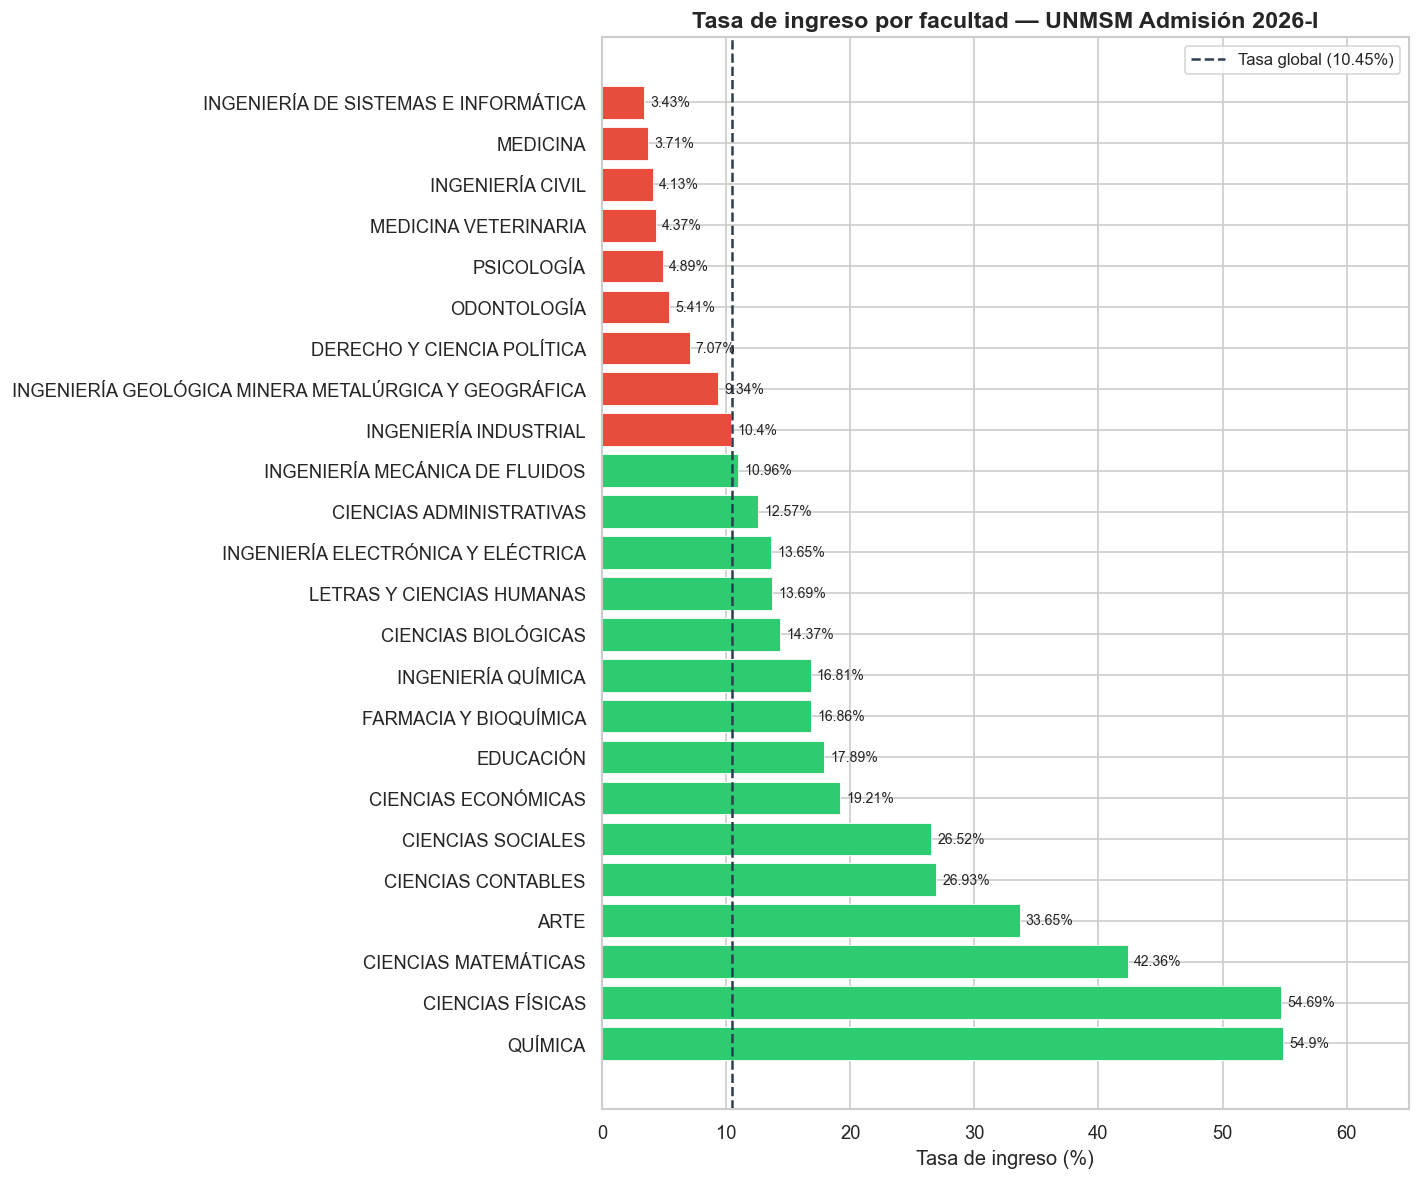

In [9]:
fig, ax = plt.subplots(figsize=(12, 10))

colores = ['#2ecc71' if t >= 10.45 else '#e74c3c' 
           for t in tasa_facultad['tasa_ingreso']]

ax.barh(
    tasa_facultad['facultad'],
    tasa_facultad['tasa_ingreso'],
    color=colores,
    edgecolor='white',
    linewidth=0.5
)

ax.axvline(x=10.45, color='#2c3e50', linestyle='--', linewidth=1.5, label='Tasa global (10.45%)')

ax.set_xlabel('Tasa de ingreso (%)', fontsize=12)
ax.set_title('Tasa de ingreso por facultad — UNMSM Admisión 2026-I', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 65)

for i, (tasa, postulantes) in enumerate(zip(tasa_facultad['tasa_ingreso'], tasa_facultad['postulantes'])):
    ax.text(tasa + 0.5, i, f'{tasa}%', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('../data/processed/tasa_ingreso_facultad.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
df_ingresante = df_activos[df_activos["ingreso"] == 1]
puntaje_minimo_escuela = df_ingresante.groupby("escuela")["puntaje"].min().reset_index()
puntaje_minimo_escuela = puntaje_minimo_escuela.sort_values("puntaje", ascending=True)
puntaje_minimo_escuela

,escuela,puntaje
84,PRESUPUESTO Y FINANZAS PÚBLICAS - S.J.L,447.00
17,AUDITORÍA EMPRESARIAL Y DEL SECTOR PÚBLICO - S...,492.62
1,ADMINISTRACIÓN - HUARAL,534.75
47,GESTIÓN TRIBUTARIA - S.J.L,571.88
71,INVESTIGACIÓN OPERATIVA,674.25
...,...,...
82,ODONTOLOGÍA,1189.25
56,INGENIERÍA DE SISTEMAS,1192.62
85,PSICOLOGÍA,1192.62
78,MEDICINA VETERINARIA,1200.62


## Nota de Calidad de Dato — Conteo de Escuelas

El dataset registra **95 escuelas profesionales** en lugar de las 81 oficiales 
de la UNMSM. Esto se debe a que la unidad de análisis es **carrera + sede** — 
una misma carrera ofertada en múltiples sedes aparece como escuela independiente.

**Desglose:**
- Lima: 83 escuelas
- Sedes descentralizadas (SJL + Huaral): 12 escuelas

Esta distinción es correcta para el análisis de admisión ya que cada combinación 
carrera + sede tiene su propio pool de postulantes, vacantes y puntaje de corte.

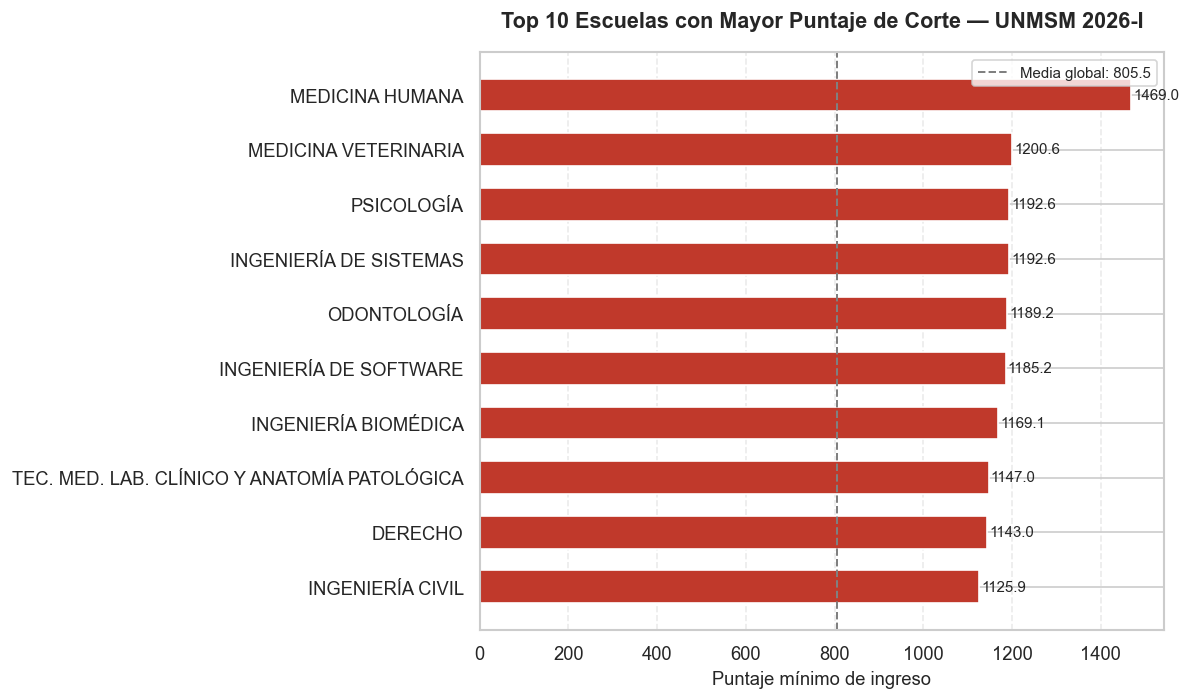

In [11]:
#Escuelas más competitivas
top_10 = puntaje_minimo_escuela.tail(10)

fig, ax = plt.subplots(figsize = (10,6))
bars = ax.barh(top_10["escuela"], top_10["puntaje"], color='#C0392B', edgecolor='white', height=0.6)
ax.axvline(x = df_activos["puntaje"].mean(), color = "gray", linestyle = "--", linewidth = 1.2, label = f"Media global: {df_activos["puntaje"].mean():.1f}" )
for bar in bars:
    width = bar.get_width()
    ax.text(width + 5, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}', va='center', fontsize=9)

ax.set_title('Top 10 Escuelas con Mayor Puntaje de Corte — UNMSM 2026-I', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Puntaje mínimo de ingreso', fontsize=11)
ax.set_ylabel('')
ax.legend(fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig('../data/processed/top10_alta_competitividad.png', dpi=150, bbox_inches='tight')
plt.show()

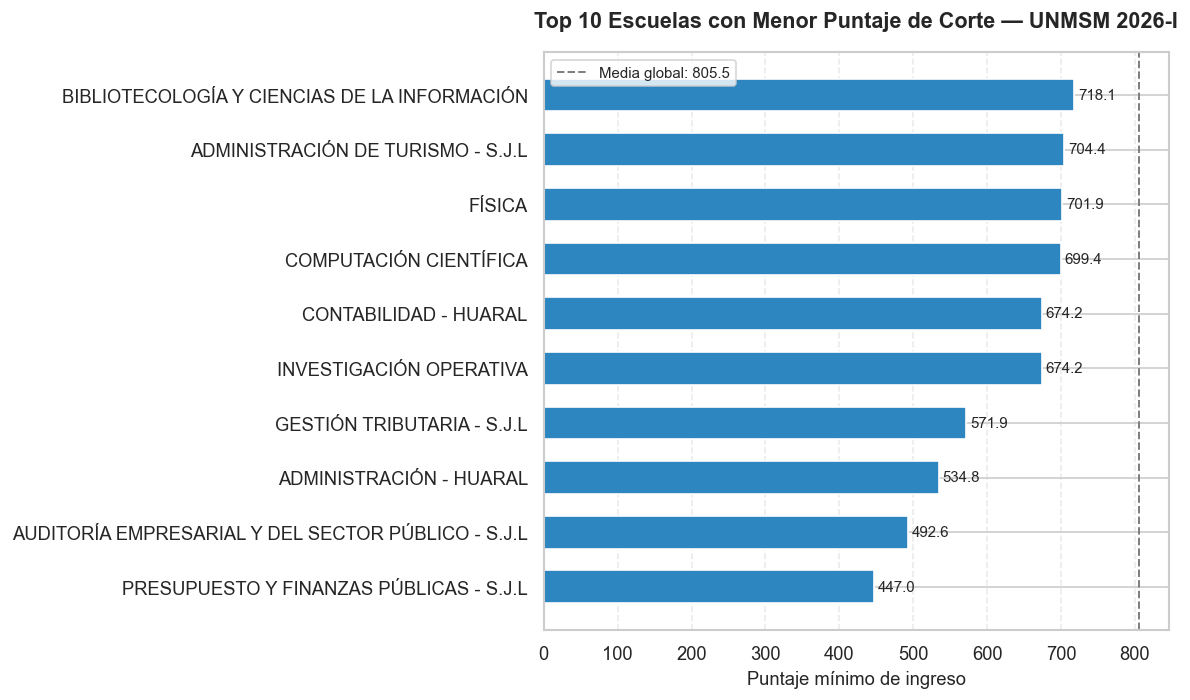

In [12]:
top_10_low = puntaje_minimo_escuela.head(10)

fig, ax = plt.subplots(figsize = (10,6))
bars = ax.barh(top_10_low["escuela"], top_10_low["puntaje"], color='#2E86C1', edgecolor='white', height=0.6)
ax.axvline(x = df_activos["puntaje"].mean(), color = "gray", linestyle = "--", linewidth=1.2, label=f"Media global: {df_activos['puntaje'].mean():.1f}")

for bar in bars:
    width = bar.get_width() #obtiene el valor de la longitud del grafico
    ax.text(width + 5, bar.get_y() + bar.get_height()/2, f"{width:.1f}", va = "center", fontsize=9)

ax.set_title('Top 10 Escuelas con Menor Puntaje de Corte — UNMSM 2026-I', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Puntaje mínimo de ingreso', fontsize=11)
ax.set_ylabel('')
ax.legend(fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig('../data/processed/top10_baja_competitividad.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
tasa_escuela = df_activos.groupby("escuela").agg(
    postulantes=("ingreso", "count"),
    ingresantes = ("ingreso", "sum") # agg se usa para aplicar una o más operaciones matematicas
).reset_index()

tasa_escuela["tasa_ingreso"] = tasa_escuela["ingresantes"]/ tasa_escuela["postulantes"]

print(tasa_escuela.shape)
print(tasa_escuela.head(10))

(95, 4)
                                             escuela  postulantes  \
0       ADMINISTRACION MARITIMA Y PORTUARIA - HUARAL           37   
1                            ADMINISTRACIÓN - HUARAL           11   
2                              ADMINISTRACIÓN - LIMA          524   
3                             ADMINISTRACIÓN - S.J.L           36   
4                   ADMINISTRACIÓN DE LA GASTRONOMÍA          130   
5  ADMINISTRACIÓN DE NEGOCIOS INTERNACIONALES - H...           31   
6  ADMINISTRACIÓN DE NEGOCIOS INTERNACIONALES - LIMA          914   
7  ADMINISTRACIÓN DE NEGOCIOS INTERNACIONALES - S...           59   
8                 ADMINISTRACIÓN DE TURISMO - HUARAL           18   
9                   ADMINISTRACIÓN DE TURISMO - LIMA          160   

   ingresantes  tasa_ingreso  
0           12          0.32  
1           10          0.91  
2           83          0.16  
3           10          0.28  
4           12          0.09  
5            9          0.29  
6           48 

In [14]:
df_scatter = puntaje_minimo_escuela.merge(tasa_escuela, on='escuela')
print(df_scatter.shape)
print(df_scatter.head(5))

(95, 5)
                                             escuela  puntaje  postulantes  \
0            PRESUPUESTO Y FINANZAS PÚBLICAS - S.J.L   447.00           18   
1  AUDITORÍA EMPRESARIAL Y DEL SECTOR PÚBLICO - S...   492.62           12   
2                            ADMINISTRACIÓN - HUARAL   534.75           11   
3                         GESTIÓN TRIBUTARIA - S.J.L   571.88           24   
4                            INVESTIGACIÓN OPERATIVA   674.25          101   

   ingresantes  tasa_ingreso  
0           18          1.00  
1           12          1.00  
2           10          0.91  
3           20          0.83  
4           49          0.49  


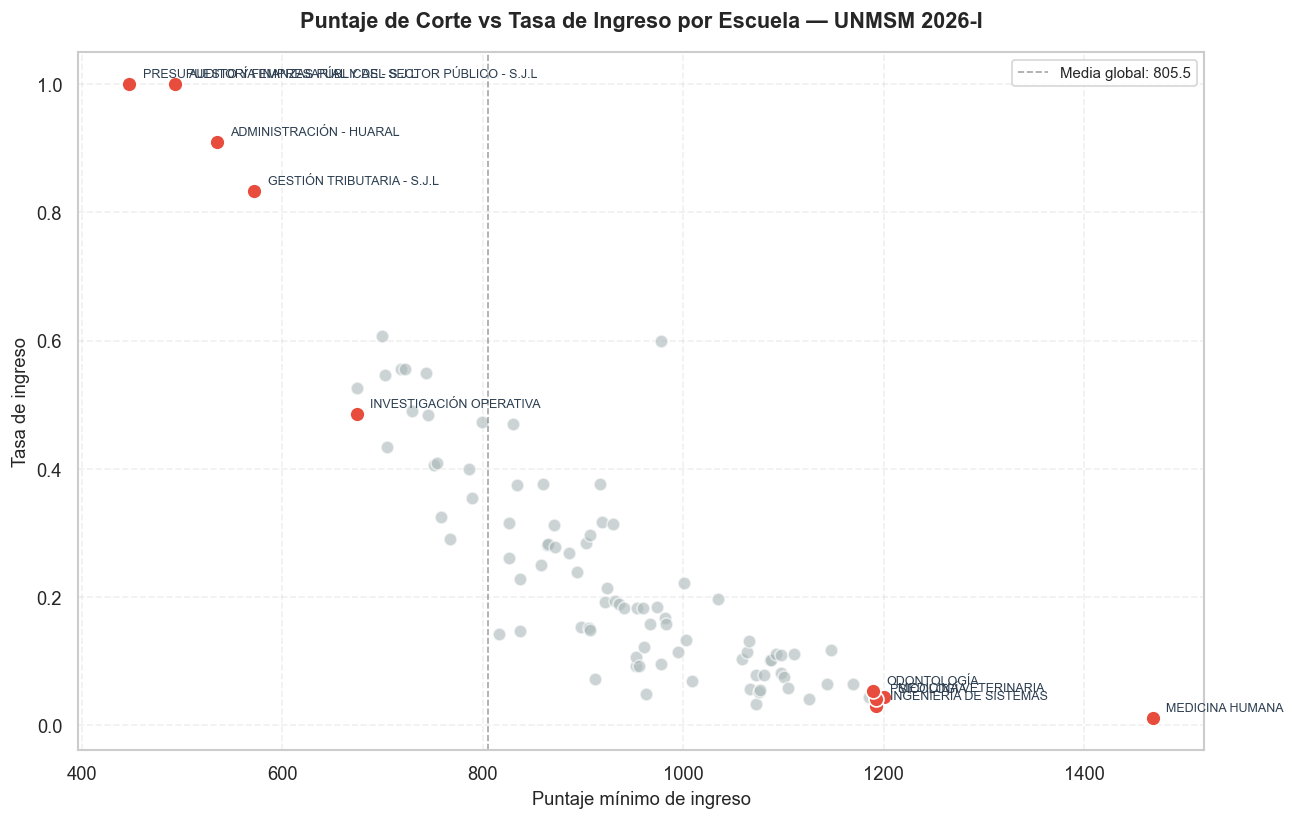

In [15]:
#Puntaje de corte vs tasa de ingreso por escuela
extremos_high = df_scatter.nlargest(5, 'puntaje')
extremos_low = df_scatter.nsmallest(5, 'puntaje')
extremos = pd.concat([extremos_high, extremos_low])

fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(df_scatter['puntaje'], df_scatter['tasa_ingreso'],
           color='#AAB7B8', alpha=0.6, edgecolors='white', s=60, zorder=2)

ax.scatter(extremos['puntaje'], extremos['tasa_ingreso'],
           color='#E74C3C', s=80, zorder=3, edgecolors='white')

for _, row in extremos.iterrows():
    ax.annotate(row['escuela'],
                xy=(row['puntaje'], row['tasa_ingreso']),
                xytext=(8, 4), textcoords='offset points',
                fontsize=7.5, color='#2C3E50')

ax.axvline(x=df_activos['puntaje'].mean(), color='gray', linestyle='--',
           linewidth=1, alpha=0.7, label=f"Media global: {df_activos['puntaje'].mean():.1f}")

ax.set_title('Puntaje de Corte vs Tasa de Ingreso por Escuela — UNMSM 2026-I',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Puntaje mínimo de ingreso', fontsize=11)
ax.set_ylabel('Tasa de ingreso', fontsize=11)
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.3)
plt.tight_layout()

plt.savefig('../data/processed/scatter_puntaje_tasa_ingreso.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔍 Insight #2 — Relación inversa entre puntaje de corte y tasa de ingreso

**Hallazgo:** Existe una relación inversamente proporcional entre el puntaje de corte 
y la tasa de ingreso por escuela. Medicina Humana es un outlier estructural — 
su puntaje de corte (1,469) supera en 270 puntos al segundo lugar.

**Contexto:** La relación inversa responde a dos factores: volumen de postulantes 
y número de vacantes por carrera. A mayor ratio postulantes/vacantes, mayor 
competencia y mayor puntaje de corte. Carreras como Física, Matemática e 
Investigación Operativa tienen tasa de ingreso alta por baja demanda, 
no por baja dificultad académica.

**Implicancia:** Un postulante que elige carrera solo por tasa de ingreso 
alta corre el riesgo de subestimar la exigencia académica. Accesibilidad de ingreso 
no equivale a facilidad de culminación.

## 🔍 Insight #3 — La sede puede determinar tu ingreso

**Hallazgo:** Las carreras en sedes descentralizadas (SJL y Huaral) tienen 
tasa de ingreso significativamente mayor y puntaje de corte menor que Lima. 
Algunas carreras registran 100% de ingresantes, evidenciando baja competencia.

**Contexto:** Las sedes descentralizadas concentran carreras con baja demanda 
de postulantes. El ratio postulantes/vacantes es bajo, lo que reduce 
la competencia y el puntaje de corte estructuralmente.

**Implicancia de negocio:** Un postulante debería evaluar postular a una sede 
descentralizada si la carrera está alineada con sus objetivos y la sede 
le queda geográficamente accesible. A nivel institucional, la UNMSM debería 
implementar estrategias para incrementar la demanda en sedes descentralizadas 
y equilibrar la distribución de postulantes entre sedes.

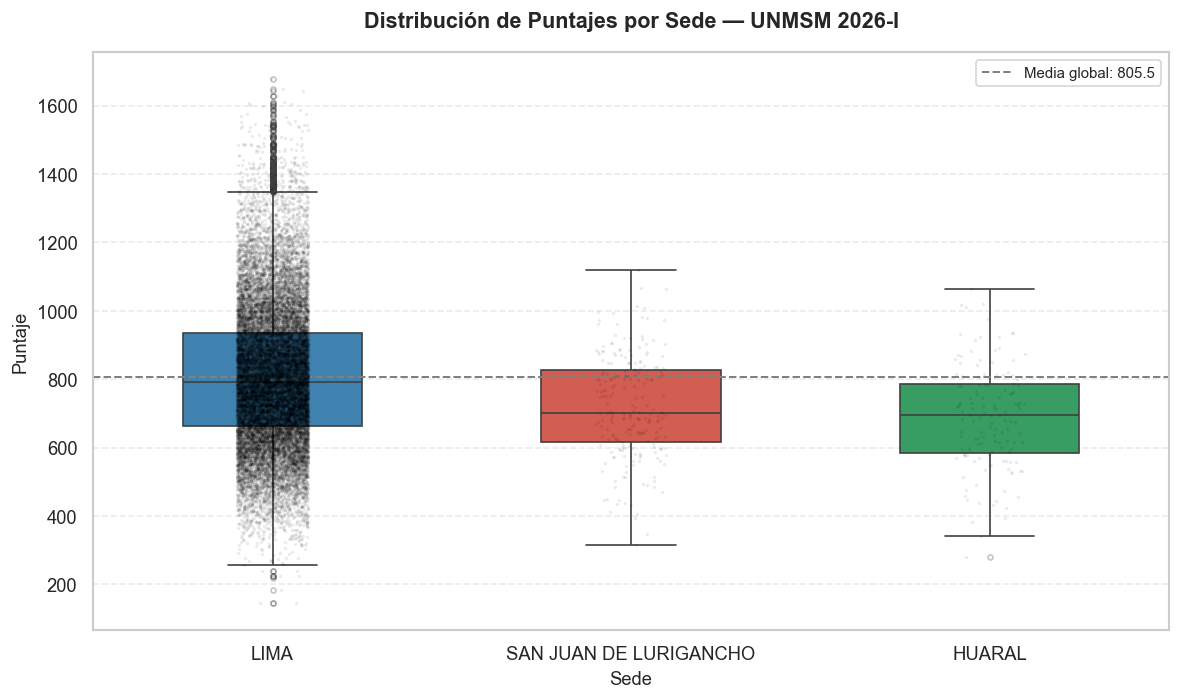

In [17]:
orden_sedes = df_activos.groupby('sede')['puntaje'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df_activos, x='sede', y='puntaje', order=orden_sedes,
            palette=['#2E86C1', '#E74C3C', '#27AE60'],
            width=0.5, flierprops=dict(marker='o', markersize=3, alpha=0.3), ax=ax)

sns.stripplot(data=df_activos, x='sede', y='puntaje', order=orden_sedes,
              color='black', alpha=0.08, size=2, jitter=True, ax=ax)

ax.axhline(y=df_activos['puntaje'].mean(), color='gray', linestyle='--',
           linewidth=1.2, label=f"Media global: {df_activos['puntaje'].mean():.1f}")

ax.set_title('Distribución de Puntajes por Sede — UNMSM 2026-I',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Sede', fontsize=11)
ax.set_ylabel('Puntaje', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig('../data/processed/distribucion_puntajes_sede.png', dpi=150, bbox_inches='tight')
plt.show()

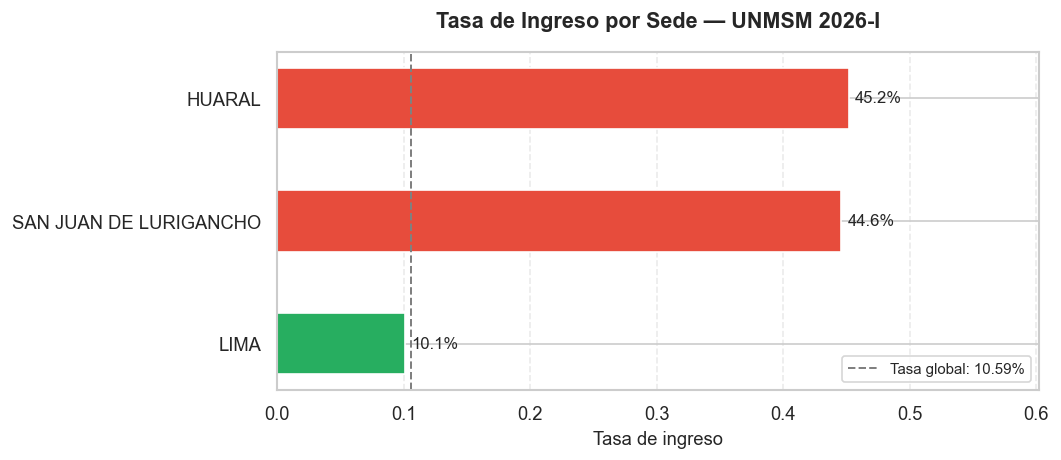

In [18]:
tasa_sede = df_activos.groupby('sede').agg(
    postulantes=('ingreso', 'count'),
    ingresantes=('ingreso', 'sum')
).reset_index()
tasa_sede['tasa_ingreso'] = tasa_sede['ingresantes'] / tasa_sede['postulantes']
tasa_sede = tasa_sede.sort_values('tasa_ingreso', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))

colors = ['#27AE60' if sede == 'LIMA' else '#E74C3C'
          for sede in tasa_sede['sede']]

bars = ax.barh(tasa_sede['sede'], tasa_sede['tasa_ingreso'],
               color=colors, edgecolor='white', height=0.5)

ax.axvline(x=df_activos['ingreso'].mean(), color='gray', linestyle='--',
           linewidth=1.2, label=f"Tasa global: {df_activos['ingreso'].mean():.2%}")

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2,
            f'{width:.1%}', va='center', fontsize=10)

ax.set_title('Tasa de Ingreso por Sede — UNMSM 2026-I',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Tasa de ingreso', fontsize=11)
ax.set_ylabel('')
ax.legend(fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_xlim(0, max(tasa_sede['tasa_ingreso']) + 0.15)
plt.tight_layout()

plt.savefig('../data/processed/tasa_ingreso_sede.png', dpi=150, bbox_inches='tight')
plt.show()